# Tracking a High-Speed Train under Biased GPS Measurements

## Roman Branovets, Skoltech, 2025

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

**Motion model**

$$
\begin{aligned}
x_i &= x_{i-1} + V_{i-1}T + \frac{a_i T^2}{2}\\
V_i &= V_{i-1} + a_i T
\end{aligned}
$$

Where $a_i$ represents state noise describing random changes in the train’s motion.

**State-space model**

$$
\begin{aligned}
X_i &= \Phi X_{i-1} + Ga_i \\
z_i &= H_i X_i + \eta_i
\end{aligned}
$$

Where

- $X_{i}$ is the state vector
- $\Phi$ is the transition matrix that relates $X_{i}$ and $X_{i-1}$
- $G$ is the input matrix that defines how the random acceleration $a_{i}$ influences the state vector
- $z_{i}$ is the measurement vector, which in this case consists of a measurement of the coordinate $x_{i}$
- $H$ is the observation matrix that relates the measurement vector to the state vector
- $n_{i}$ is the measurement noise with the covariance matrix $R_{i}$

### Step I. Filtering the data

1. Loading measurements of position in meters, provided by GPS with 2 seconds interval

In [2]:
data = np.loadtxt("GPS.txt")
t = 2

In [3]:
#transition matrix
fi=np.matrix([[1,t],[0,1]])
#input matrix
g=np.matrix([[(t**2)/2],[t]])
#observation matrix
h=np.matrix([1,0])
#state vector
X = np.zeros((len(data), 2, 1))

2. Run Kalman filter on the provided train GPS trajectory data

Initial filtered estimate $ X_{0,0} $ of state vector $X_0$:

$$
X_{0,0} = \begin{vmatrix}
x_0 \\
V_0
\end{vmatrix} = \begin{vmatrix}
2 \\
0
\end{vmatrix}
$$

3. Initial filtration error covariance matrix

$$
P_{0,0} = \begin{vmatrix}
\sigma^2_{x_{0,0}} & 0 \\
0 & \sigma^2_{V_{0,0}}
\end{vmatrix} = \begin{vmatrix}
100 & 0 \\
0 & 100
\end{vmatrix}
$$

Variance of state noise: 
$$
\sigma_a^2 = 0.2^2
$$

Variance of measurement noise: 
$$
\sigma_\eta^2 = 20^2
$$

In [4]:
#Initial filtered estimate
X[0]=np.matrix([[2],[0]])
#Filtration error covariance matrix
P=np.zeros((len(data), 2, 2))
P[0]=np.matrix([[100, 0], [0, 100]])
#Covariance matrix
Q=(g@g.T)*(0.2**2)
R = np.array(20**2)
K = np.zeros((len(data), 2, 1))
for i in range(1,len(data)):
    #step of prediction
    X[i]=fi@X[i-1]
    P[i]=(fi@P[i-1]@fi.T)+Q
    #step of filtration
    E=h@P[i]@h.T + R
    K[i]=(P[i]@h.T)/E
    X[i]=X[i]+K[i]*(data[i]-h@X[i])
    P[i]=(np.identity(2)-K[i]@h)@P[i]

4. Plot: GPS measurements of the position 𝑥, filter estimates for both the coordinate 𝑥 and
velocity 𝑉.

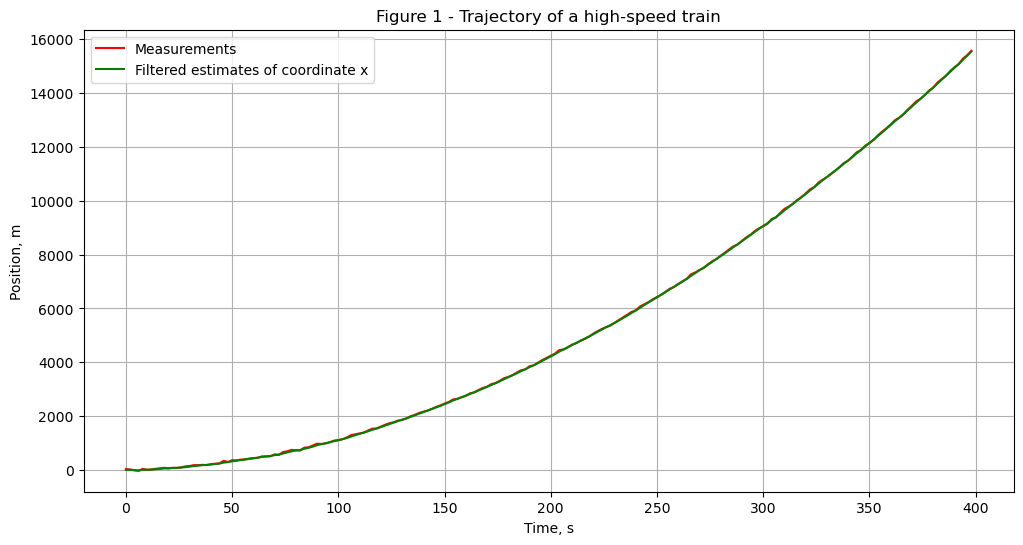

In [5]:
#Plots of GPS measurements and filtered estimates
plt.figure(figsize=(12, 6))
plt.plot(np.arange(0, 400, 2), data, color='red', label='Measurements')
plt.plot(np.arange(0, 400, 2), X[:,0,0], color='green', label='Filtered estimates of coordinate x')
plt.title('Figure 1 - Trajectory of a high-speed train')
plt.xlabel('Time, s')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

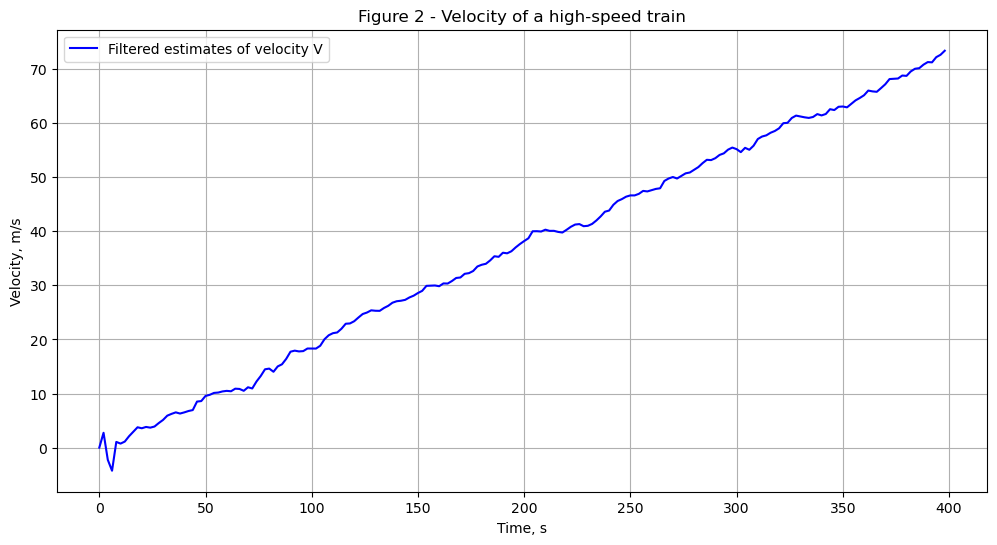

In [6]:
#Plots of filtered estimates of velocity
plt.figure(figsize=(12, 6))
plt.plot(np.arange(0, 400, 2), X[:,1,0], color='blue',  label='Filtered estimates of velocity V')
plt.title('Figure 2 - Velocity of a high-speed train')
plt.xlabel('Time, s')
plt.ylabel('Velocity, m/s')
plt.legend()
plt.grid()
plt.show()

5. Let's zoom in our plot to observe the results.

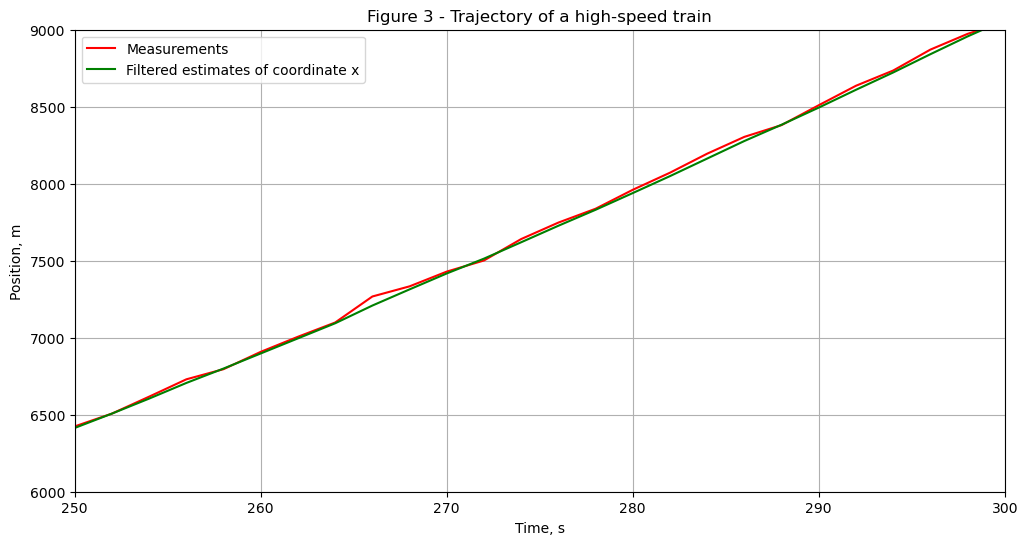

In [7]:
#Plots of GPS measurements and filtered estimates
plt.figure(figsize=(12, 6))
plt.plot(np.arange(0, 400, 2), data, color='red', label='Measurements')
plt.plot(np.arange(0, 400, 2), X[:,0,0], color='green', label='Filtered estimates of coordinate x')
plt.title('Figure 3 - Trajectory of a high-speed train')
plt.xlabel('Time, s')
plt.ylabel('Position, m')
plt.xlim(250,300)
plt.ylim(6000,9000)
plt.legend()
plt.grid()
plt.show()

We see that at this interval, the filter estimates do not deviate, while there is an offset between the measurements and the filtered position. We can conclude that the filter appears overconfident or systematically shifted

### Step II. Checking residuals for signs of bias

Filter residuals

$$r_k = z_k - H X_{k,k-1}$$
Variance of residuals

$$S_k = H P_{k,k-1} H^{\mathrm{T}} + R$$

1. Calculate the mean of residual

In [8]:
#Initial filtered estimate
X[0]=np.matrix([[2],[0]])
#Filtration error covariance matrix
P=np.zeros((len(data), 2, 2))
P[0]=np.matrix([[100, 0], [0, 100]])
#Covariance matrix
Q=(g@g.T)*(0.2**2)
R = np.array(20**2)
K = np.zeros((len(data), 2, 1))
# r - residuals
r = np.zeros(len(data))
# s - standart deviations of the residuals
s = np.zeros(len(data))
for i in range(1,len(data)):
    #step of prediction
    X[i]=fi@X[i-1]
    P[i]=(fi@P[i-1]@fi.T)+Q
    r[i] = data[i] - (h@X[i])[0,0]
    s[i] = (h@P[i]@h.T)[0, 0] + R
    #step of filtration
    E=h@P[i]@h.T + R
    K[i]=(P[i]@h.T)/E
    X[i]=X[i]+K[i]*(data[i]-h@X[i])
    P[i]=(np.identity(2)-K[i]@h)@P[i]
resmean = np.sum(r) / len(r)
print(f'Mean of residual: {resmean}')

Mean of residual: 20.688187220861764


2. Now let’s see how well the filter keeps the train “on track”. Plot the residuals $𝑟_𝑘$ together with
the limits $±√𝑆_𝑘$ to visualize how they compare to the standard deviation predicted by the
filter.


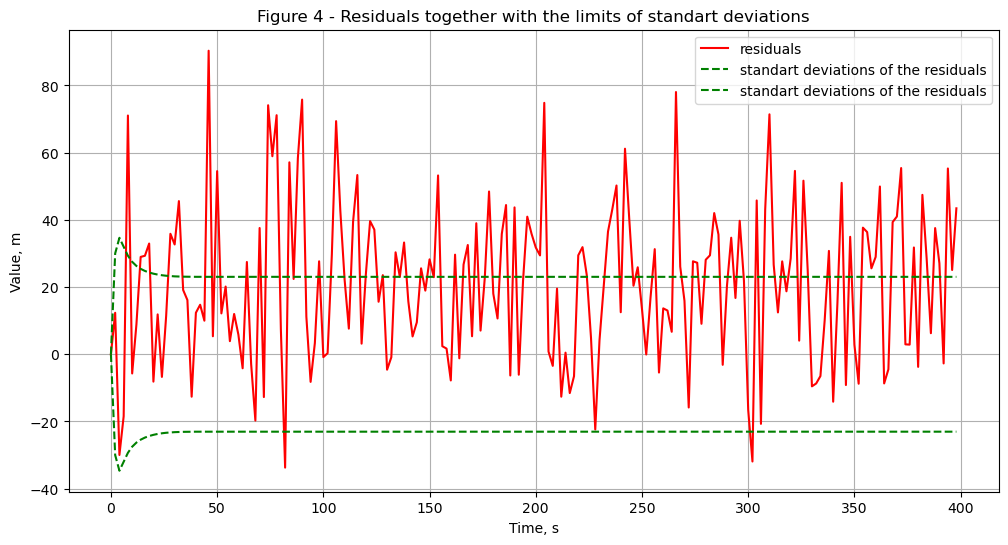

In [9]:
#Plots of residuals together with limits of standart deviations of the residuals
plt.figure(figsize=(12, 6))
plt.plot(np.arange(0, 400, 2), r, color='red',  label='residuals')
plt.plot(np.arange(0, 400, 2), np.sqrt(s), color='green', linestyle='--',  label='standart deviations of the residuals')
plt.plot(np.arange(0, 400, 2), -np.sqrt(s), color='green', linestyle='--',  label='standart deviations of the residuals')
plt.title('Figure 4 - Residuals together with the limits of standart deviations')
plt.xlabel('Time, s')
plt.ylabel('Value, m')
plt.legend()
plt.grid()
plt.show()

Residuals frequently exceed limits of standart deviation of the residuals and remain systematically above or below zero, it
suggests that the model or measurements are biased.

### Step III. Correcting the bias

Experimental tests revealed a small constant drift in the system dynamics, meaning the process
noise has a nonzero mean $𝑞 = 0.2$

$$
\begin{aligned}
X_{k, k-1} &= \Phi_{k, k-1} X_{k-1, k-1} + Gq \\
\end{aligned}
$$

In [10]:
q = 0.2

#Initial filtered estimate
X[0]=np.matrix([[2],[0]])
#Filtration error covariance matrix
P=np.zeros((len(data), 2, 2))
P[0]=np.matrix([[100, 0], [0, 100]])
#Covariance matrix
Q=(g@g.T)*(0.2**2)
R = np.array(20**2)
K = np.zeros((len(data), 2, 1))
# r - residuals
r = np.zeros(len(data))
# s - standart deviations of the residuals
s = np.zeros(len(data))
for i in range(1,len(data)):
    #step of prediction
    X[i]=fi@X[i-1] + g*q
    P[i]=(fi@P[i-1]@fi.T)+Q
    r[i] = data[i] - (h@X[i])[0,0]
    s[i] = (h@P[i]@h.T)[0, 0] + R
    #step of filtration
    E=h@P[i]@h.T + R
    K[i]=(P[i]@h.T)/E
    X[i]=X[i]+K[i]*(data[i]-h@X[i])
    P[i]=(np.identity(2)-K[i]@h)@P[i]
resmean = np.sum(r) / len(r)
print(f'Mean of residual: {resmean}')

Mean of residual: -1.131916489539187


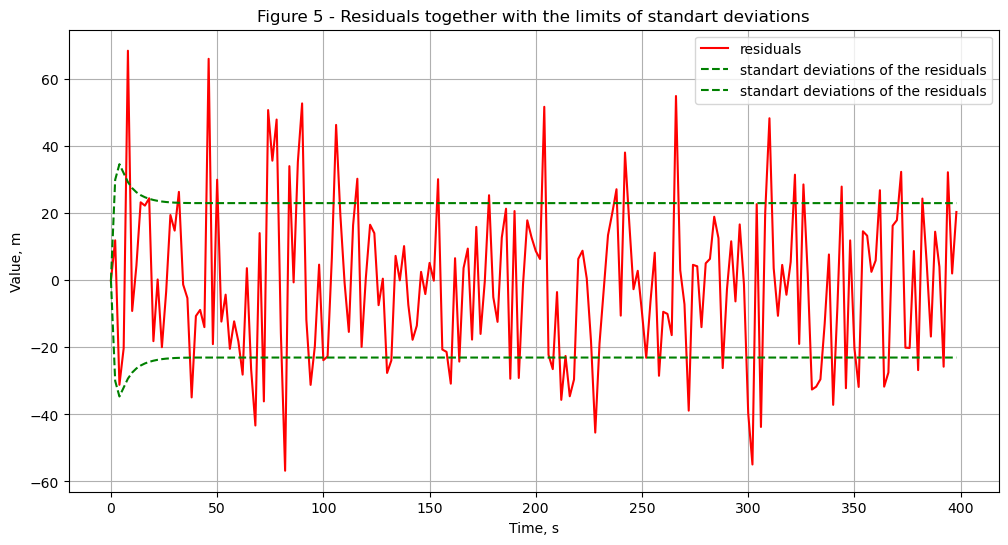

In [11]:
#Plots of residuals together with limits of standart deviations of the residuals
plt.figure(figsize=(12, 6))
plt.plot(np.arange(0, 400, 2), r, color='red',  label='residuals')
plt.plot(np.arange(0, 400, 2), np.sqrt(s), color='green', linestyle='--',  label='standart deviations of the residuals')
plt.plot(np.arange(0, 400, 2), -np.sqrt(s), color='green', linestyle='--',  label='standart deviations of the residuals')
plt.title('Figure 5 - Residuals together with the limits of standart deviations')
plt.xlabel('Time, s')
plt.ylabel('Value, m')
plt.legend()
plt.grid()
plt.show()

We see, that the mean residual move closer to zero and most residuals stay within the corridor $±√𝑆_𝑘$, the filter’s estimation ($𝑆_𝑘$) matches reality
($𝑟_𝑘$) quite well.

### Step IV: Analyzing the true error when ignoring bias of state noise

State-Space model with bias of state noise is presented as
$$𝑋_𝑘 = Φ 𝑋_{𝑘−1} + 𝐺(𝑎_𝑘 + 𝑞)$$

1. Calculate iteratively $𝜇_{𝑘,𝑘−1}$ and $𝜇_{𝑘,k}$ starting with $$
𝜇_{0,0} = \begin{vmatrix}
0 \\
0
\end{vmatrix}
$$

$$
\mu_{k,k-1}=\Phi\mu_{k-1,k-1}+Gq
$$
$$
\mu_{k,k}=(I-K_kH)\mu_{k,k-1}
$$

In [12]:
q = 0.2

#Initial filtered estimate
X[0]=np.matrix([[2],[0]])
#Filtration error covariance matrix
P=np.zeros((len(data), 2, 2))
P[0]=np.matrix([[100, 0], [0, 100]])
#Covariance matrix
Q=(g@g.T)*(0.2**2)
R = np.array(20**2)
K = np.zeros((len(data), 2, 1))
# r - residuals
r = np.zeros(len(data))
# s - standart deviations of the residuals
s = np.zeros(len(data))
# mu - Mathematical expectation of error
mu = np.zeros((len(data), 2, 1))
mu[0] = np.matrix([[0],[0]])
mu_vis = np.zeros((len(data), 2, 1))
mu_vis[0] = np.matrix([[0],[0]])
for i in range(1,len(data)):
    #step of prediction
    X[i]=fi@X[i-1] + g*q
    P[i]=(fi@P[i-1]@fi.T)+Q
    r[i] = data[i] - (h@X[i])[0,0]
    s[i] = (h@P[i]@h.T)[0, 0] + R
    mu[i] = fi@mu[i-1] + g*q
    mu_vis[i] = fi@mu[i-1] + g*q
    #step of filtration
    E=h@P[i]@h.T + R
    K[i]=(P[i]@h.T)/E
    X[i]=X[i]+K[i]*(data[i]-h@X[i])
    P[i]=(np.identity(2)-K[i]@h)@P[i]
    mu[i] = (np.identity(2)-K[i]@h)@mu[i]

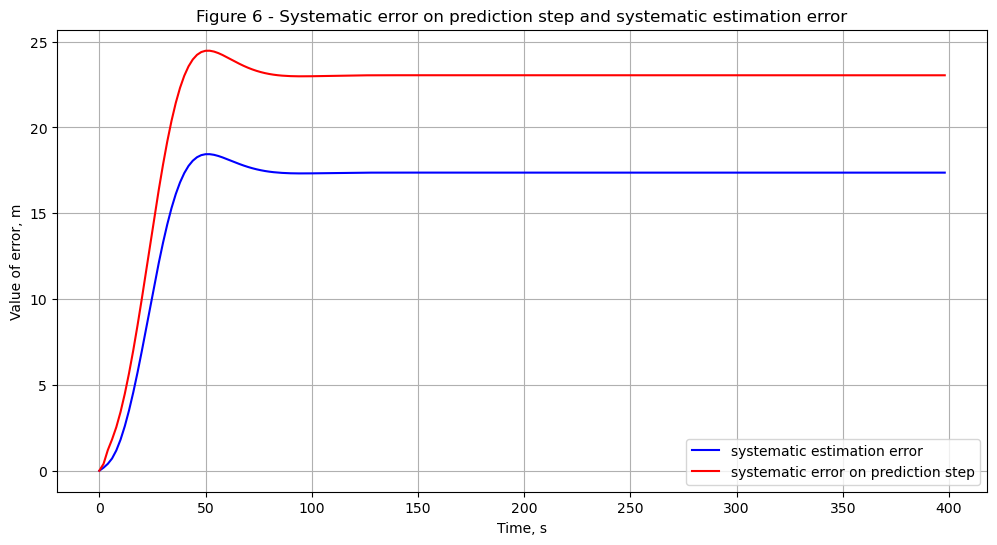

In [13]:
#Plot of the systematic error on prediction step and systematic estimation error
plt.figure(figsize=(12, 6))
plt.plot(np.arange(0, 400, 2), mu[:,0,0], color="blue",  label='systematic estimation error')
plt.plot(np.arange(0, 400, 2), mu_vis[:,0,0], color="red",  label='systematic error on prediction step')
plt.title('Figure 6 - Systematic error on prediction step and systematic estimation error')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.legend()
plt.grid()
plt.show()

We see that the prediction step has a higher systematic error. After about 75 seconds, the systematic estimation error was established

2. Calculate true full error:

In [14]:
error = np.zeros((len(data), 2, 1))
for i in range(len(data)):
    error[i, 0, 0] = sqrt(P[i, 0, 0] + mu[i, 0, 0]**2)
    error[i, 1, 0] = sqrt(P[i, 1, 1] + mu[i, 1, 0]**2)

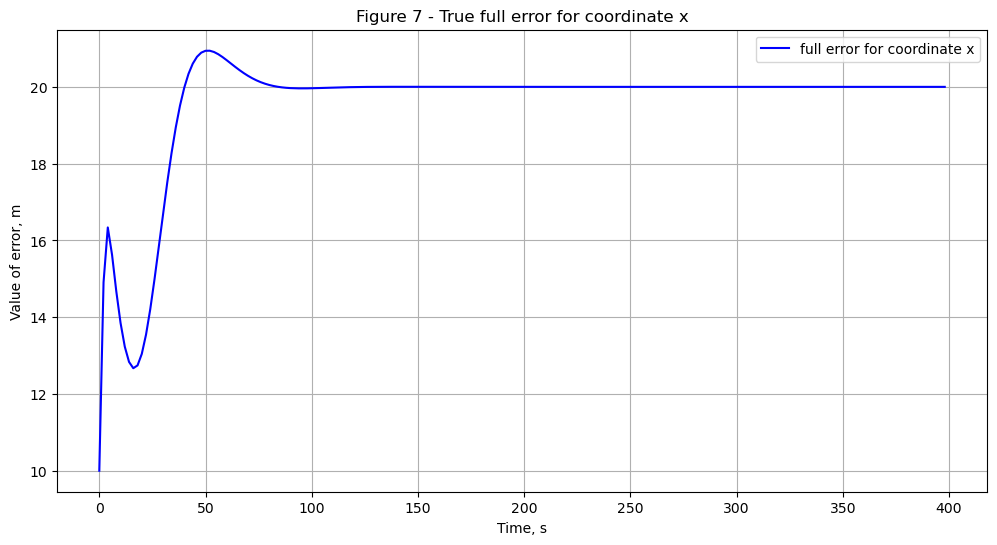

In [15]:
#Plot of the true full error for coordinate x
plt.figure(figsize=(12, 6))
plt.plot(np.arange(0, 400, 2), error[:,0,0], color="blue",  label='full error for coordinate x')
plt.title('Figure 7 - True full error for coordinate x')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.legend()
plt.grid()
plt.show()

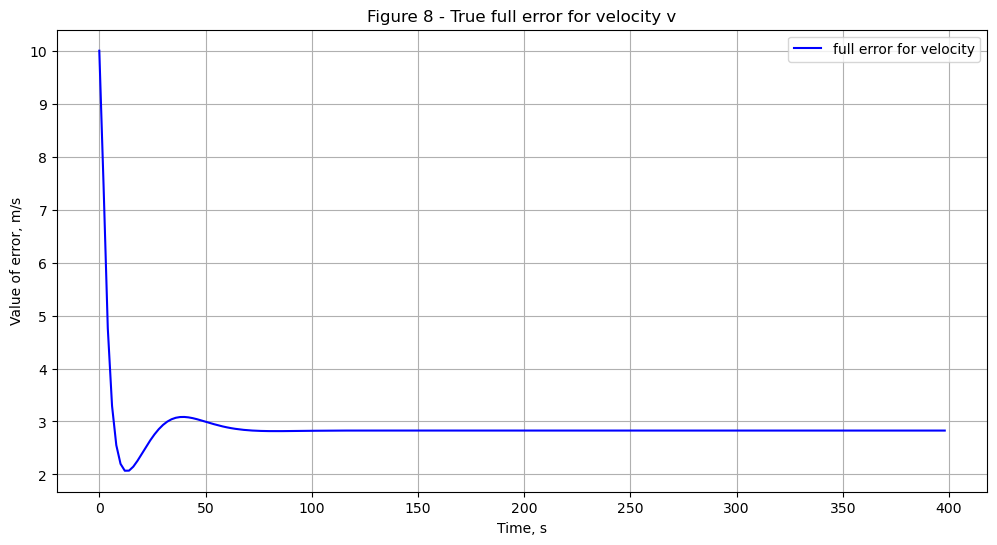

In [16]:
#Plot of the true full error for velocity v
plt.figure(figsize=(12, 6))
plt.plot(np.arange(0, 400, 2), error[:,1,0], color="blue",  label='full error for velocity')
plt.title('Figure 8 - True full error for velocity v')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m/s')
plt.legend()
plt.grid()
plt.show()

Let's Compare the resulting true error with the standard deviation from the filter (matrices 𝑃), and
also with the standard deviation of the measurement noise.

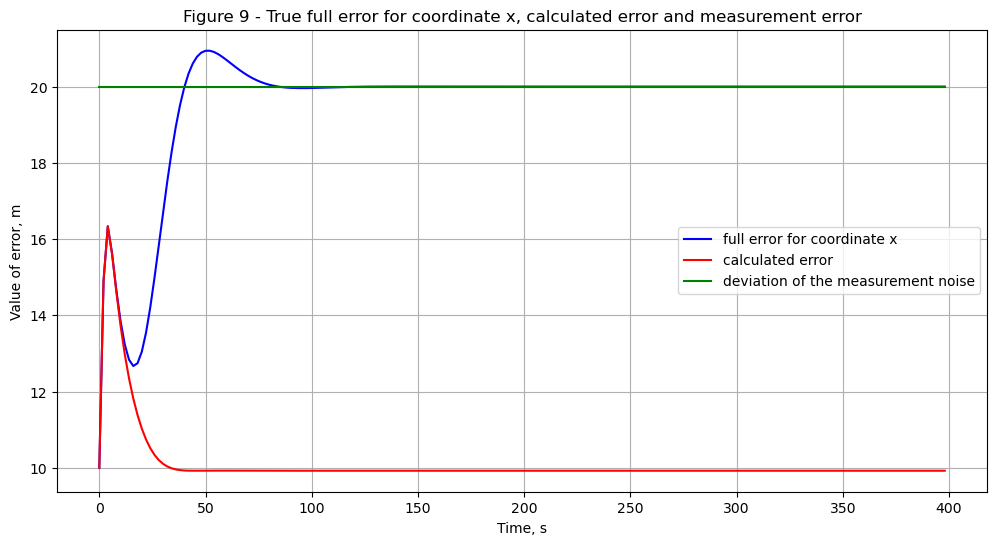

In [17]:
#Plot of the true full error for coordinate x, calculated error and measurement error
plt.figure(figsize=(12, 6))
plt.plot(np.arange(0, 400, 2), error[:,0,0], color="blue",  label='full error for coordinate x')
plt.plot(np.arange(0, 400, 2), np.sqrt(P[:,0,0]), color="red",  label='calculated error')
plt.plot(np.arange(0, 400, 2), np.repeat(20, 200), color="green",  label='deviation of the measurement noise')
plt.title('Figure 9 - True full error for coordinate x, calculated error and measurement error')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.legend()
plt.grid()
plt.show()

We see that the standard deviation from the filter is 2 times lower than the true error.
In addition, we see that the true error turned out to be equal to the standard deviation of the measurement noise.  It can be concluded that the filter, which ignores the bias, ineffectively filters the measurements. The filter does not understand that there is an offset. We can trust filter errors derived from
matrices P only when there are no systematic errors in the model.

**Conclusion:**

Initially, we used a filter that does not take into account that the model or measurements are biased. We found out that that the filter, which ignores the bias, ineffectively filters the measurements. Further, when we introduced the process noise mean q = 0.2, we improved the filter readings and the residuals began to resemble white noise. As a result, we found that the standard deviation from the filter was 2 times less than the true error, which indicates that the filter is overly confident in its estimates.  The final conclusion can be drawn that if you do not take into account the systematic error, the filter becomes overconfident and gives incorrect estimates.

Thus, we realized that the classical Kalman filter model is incapable of accounting for measurement bias. We studied its sensitivity to this case. Thus, we refined the Kalman filter model and were able to obtain a model capable of accounting for bias, thereby achieving a better result.

**Learning log:**

What we learned: 

We learned how to assess whether there is a systematic error in the model and how to estimate its value. Also we learned how to take bias of random accelerations
into account in Kalman filter

We learned how to work with biases in factors and refined a recurrence model that can account for biases and obtain valid data associated with the corresponding processing. And we learned how to evaluate a true full error.

What difficulties we faced:

It was difficult to see the displacement on the graph of the measured trajectory and the trajectory after the filter.

We encountered difficulties in understanding the representation of value offsets and how to take them into account in filtering equations.